# Execution notebook: noisy subnormalised-state simulation

This notebook uses the framework already built in the project to run the workflow:

1. generate random paper-style subnormalised one-qubit target states,
2. prepare them with the one-ancilla dilation circuit,
3. inject circuit noise and readout noise,
4. do one-qubit tomography on the prepared state,
5. compute fidelity and Frobenius distance,
6. average over all generated states,
7. repeat for different sample sizes.


In [1]:

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from algo.dilation_algo import hadamard, build_state_preparation_dilation, density_matrix_from_state
from subnorm.state_preparation import paper_style_state_preparation_data
from noise.noise_simulation import (
    SimpleNISQNoiseParameters,
    apply_amplitude_phase_damping,
    apply_local_depolarizing,
    apply_global_two_qubit_depolarizing,
    noisy_single_qubit_measurement,
)

from metric.tomography import (
    basis_probabilities,
    expectation_from_counts,
    linear_inversion_density_matrix,
    project_to_physical_density_matrix,
)
from metric.fidelity_frobenius import evaluate_fidelity_frobenius, summarize_metric_results



## Configuration

You can change the number of generated states, the sample-size sweep, and the phenomenological NISQ noise parameters here.

Interpretation used in this notebook:
- `sample_size` = ancilla readout shots used to estimate the success probability, and also the number of shots per tomography basis `X`, `Y`, `Z`.
- one system qubit is prepared, so the unnormalised reconstructed density is recovered as `2 * p_success * rho_cond`.


In [2]:

NUM_STATES = 98
SAMPLE_SIZES = [64, 256, 1024, 4096, 16384]
STATE_SEED = 1234
BASE_RNG_SEED = 2026

noise_params = SimpleNISQNoiseParameters(
    t1_system=120.0,
    t2_system=90.0,
    t1_ancilla=110.0,
    t2_ancilla=85.0,
    one_qubit_gate_time=0.035,
    two_qubit_gate_time=0.30,
    p1q_depolarizing=5e-4,
    p2q_depolarizing=8e-3,
    readout_p0_to_1_system=0.020,
    readout_p1_to_0_system=0.040,
    readout_p0_to_1_ancilla=0.015,
    readout_p1_to_0_ancilla=0.030,
)

noise_params


SimpleNISQNoiseParameters(t1_system=120.0, t2_system=90.0, t1_ancilla=110.0, t2_ancilla=85.0, one_qubit_gate_time=0.035, two_qubit_gate_time=0.3, p1q_depolarizing=0.0005, p2q_depolarizing=0.008, readout_p0_to_1_system=0.02, readout_p1_to_0_system=0.04, readout_p0_to_1_ancilla=0.015, readout_p1_to_0_ancilla=0.03)

## Circuit and tomography helpers

Circuit used for the state-preparation stage:

- start from `|0>_ancilla |0>_system`,
- apply `H` on the system qubit to create the uniform superposition input,
- apply `H` on the ancilla,
- apply the diagonal dilation unitary `U_\Sigma`,
- apply the final `H` on the ancilla,
- postselect ancilla outcome `0`.

Noise model used in the notebook:
- amplitude damping and dephasing on both qubits during each gate layer,
- one-qubit depolarizing noise on one-qubit layers,
- two-qubit depolarizing noise on the diagonal-dilation layer,
- ancilla readout error for postselection,
- system readout error and finite-shot sampling during tomography.


In [3]:

H = hadamard()
I2 = np.eye(2, dtype=complex)


def apply_one_qubit_layer_noise(rho_two_qubit, params):
    out = np.asarray(rho_two_qubit, dtype=complex)
    for target, t1, t2 in (
        (0, params.t1_ancilla, params.t2_ancilla),
        (1, params.t1_system, params.t2_system),
    ):
        out = apply_amplitude_phase_damping(
            out,
            target=target,
            num_qubits=2,
            duration=params.one_qubit_gate_time,
            t1=t1,
            t2=t2,
        )
        if params.p1q_depolarizing > 0.0:
            out = apply_local_depolarizing(
                out,
                target=target,
                num_qubits=2,
                probability=params.p1q_depolarizing,
            )
    return np.asarray(out, dtype=complex)


def apply_two_qubit_layer_noise(rho_two_qubit, params):
    out = np.asarray(rho_two_qubit, dtype=complex)
    for target, t1, t2 in (
        (0, params.t1_ancilla, params.t2_ancilla),
        (1, params.t1_system, params.t2_system),
    ):
        out = apply_amplitude_phase_damping(
            out,
            target=target,
            num_qubits=2,
            duration=params.two_qubit_gate_time,
            t1=t1,
            t2=t2,
        )
    if params.p1q_depolarizing > 0.0:
        for target in (0, 1):
            out = apply_local_depolarizing(
                out,
                target=target,
                num_qubits=2,
                probability=params.p1q_depolarizing,
            )
    if params.p2q_depolarizing > 0.0:
        out = apply_global_two_qubit_depolarizing(
            out,
            probability=params.p2q_depolarizing,
        )
    return np.asarray(out, dtype=complex)


def run_noisy_state_preparation_circuit(sample, params):
    diagonal_dilation = build_state_preparation_dilation(sample.target_subnormalized_state)
    U_sigma = diagonal_dilation.unitary_dilation

    H_system = np.kron(I2, H)
    H_ancilla = np.kron(H, I2)

    psi_in = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    rho = density_matrix_from_state(psi_in)

    rho = H_system @ rho @ H_system.conj().T
    rho = apply_one_qubit_layer_noise(rho, params)

    rho = H_ancilla @ rho @ H_ancilla.conj().T
    rho = apply_one_qubit_layer_noise(rho, params)

    rho = U_sigma @ rho @ U_sigma.conj().T
    rho = apply_two_qubit_layer_noise(rho, params)

    rho = H_ancilla @ rho @ H_ancilla.conj().T
    rho = apply_one_qubit_layer_noise(rho, params)

    return np.asarray(rho, dtype=complex)


def extract_observed_success_branch(rho_two_qubit, params, shots, rng):
    rho = np.asarray(rho_two_qubit, dtype=complex)
    rho_00 = rho[:2, :2]
    rho_11 = rho[2:, 2:]

    p_true_0 = float(np.real(np.trace(rho_00)))
    p_true_1 = float(np.real(np.trace(rho_11)))

    ancilla_measurement = noisy_single_qubit_measurement(
        [p_true_0, p_true_1],
        p0_to_1=params.readout_p0_to_1_ancilla,
        p1_to_0=params.readout_p1_to_0_ancilla,
        shots=shots,
        rng=rng,
    )

    if shots is None:
        p_observed_0 = float(ancilla_measurement.observed_probabilities[0])
    else:
        p_observed_0 = ancilla_measurement.counts['0'] / shots

    rho_observed_0 = (
        (1.0 - params.readout_p0_to_1_ancilla) * rho_00
        + params.readout_p1_to_0_ancilla * rho_11
    )
    rho_conditional = rho_observed_0 / np.trace(rho_observed_0)

    return {
        'p_true_success': p_true_0,
        'p_observed_success': float(p_observed_0),
        'rho_conditional_observed': np.asarray(rho_conditional, dtype=complex),
        'ancilla_measurement': ancilla_measurement,
    }


def perform_noisy_single_qubit_tomography(rho_conditional, params, shots, rng):
    measured_expectations = {}
    observed_basis_probabilities = {}
    basis_counts = {}

    for basis in ('X', 'Y', 'Z'):
        probs = basis_probabilities(rho_conditional, basis)
        measurement = noisy_single_qubit_measurement(
            [probs['0'], probs['1']],
            p0_to_1=params.readout_p0_to_1_system,
            p1_to_0=params.readout_p1_to_0_system,
            shots=shots,
            rng=rng,
        )
        observed_basis_probabilities[basis] = {
            '0': float(measurement.observed_probabilities[0]),
            '1': float(measurement.observed_probabilities[1]),
        }
        if shots is None:
            measured_expectations[basis] = float(
                measurement.observed_probabilities[0] - measurement.observed_probabilities[1]
            )
            basis_counts[basis] = None
        else:
            measured_expectations[basis] = expectation_from_counts(measurement.counts)
            basis_counts[basis] = measurement.counts

    rho_linear = linear_inversion_density_matrix(measured_expectations, trace=1.0)
    rho_physical = project_to_physical_density_matrix(rho_linear)

    return {
        'measured_expectations': measured_expectations,
        'basis_counts': basis_counts,
        'observed_basis_probabilities': observed_basis_probabilities,
        'rho_linear': np.asarray(rho_linear, dtype=complex),
        'rho_physical': np.asarray(rho_physical, dtype=complex),
    }


def run_single_state_pipeline(sample, params, sample_size, rng):
    rho_two_qubit = run_noisy_state_preparation_circuit(sample, params)
    postselection = extract_observed_success_branch(rho_two_qubit, params, sample_size, rng)
    tomography = perform_noisy_single_qubit_tomography(
        postselection['rho_conditional_observed'],
        params,
        sample_size,
        rng,
    )
    reconstructed_subnormalized_density = 2.0 * postselection['p_observed_success'] * tomography['rho_physical']
    metric_result = evaluate_fidelity_frobenius(sample.exact_density_matrix, reconstructed_subnormalized_density)
    return {
        'rho_two_qubit_final': rho_two_qubit,
        'postselection': postselection,
        'tomography': tomography,
        'reconstructed_subnormalized_density': reconstructed_subnormalized_density,
        'metric_result': metric_result,
    }


def run_sample_size_sweep(samples, params, sample_sizes, base_seed=0):
    summary_rows = []
    detailed_results = {}

    for sample_size in sample_sizes:
        rng = np.random.default_rng(base_seed + int(sample_size))
        metric_results = []
        per_state_results = []

        for sample in samples:
            result = run_single_state_pipeline(sample, params, sample_size, rng)
            per_state_results.append(result)
            metric_results.append(result['metric_result'])

        summary = summarize_metric_results(metric_results, sample_size=sample_size)
        summary_rows.append(
            {
                'sample_size': summary.sample_size,
                'mean_fidelity': summary.mean_fidelity,
                'std_fidelity': summary.std_fidelity,
                'mean_frobenius_distance': summary.mean_frobenius_distance,
                'std_frobenius_distance': summary.std_frobenius_distance,
            }
        )
        detailed_results[sample_size] = per_state_results

    return pd.DataFrame(summary_rows), detailed_results


## Generate the random target ensemble

In [4]:

samples, ensemble_summary = paper_style_state_preparation_data(
    num_states=NUM_STATES,
    seed=STATE_SEED,
    simulate_dilation=False,
)

print(ensemble_summary)
print(f'Number of generated target states: {len(samples)}')


SubnormalizedStateEnsembleSummary(num_states=98, mean_norm=0.7114463976015258, std_norm=0.16020229808016978, mean_trace=0.5318207529703561, std_trace=0.21434829705755293, min_norm=0.22560082555771788, max_norm=0.9632961741852678)
Number of generated target states: 98


## Single-state sanity check

In [5]:

example_sample = samples[0]
example_rng = np.random.default_rng(BASE_RNG_SEED)
example_result = run_single_state_pipeline(
    example_sample,
    noise_params,
    sample_size=SAMPLE_SIZES[0],
    rng=example_rng,
)

print('Target subnormalised state vector:')
print(example_sample.target_subnormalized_state)
print()
print('Exact target unnormalised density matrix:')
print(example_sample.exact_density_matrix)
print()
print('Observed ancilla success probability:')
print(example_result['postselection']['p_observed_success'])
print()
print('Tomography reconstructed unnormalised density matrix:')
print(example_result['reconstructed_subnormalized_density'])
print()
print('Fidelity and Frobenius distance:')
print(example_result['metric_result'])


Target subnormalised state vector:
[-0.40787983+0.21966307j  0.01630157+0.74084496j]

Exact target unnormalised density matrix:
[[0.21461782+4.27894175e-18j 0.15608719+3.05756567e-01j]
 [0.15608719-3.05756567e-01j 0.54911699+7.01413762e-19j]]

Observed ancilla success probability:
0.34375

Tomography reconstructed unnormalised density matrix:
[[0.21484375+0.j         0.11816406+0.24707031j]
 [0.11816406-0.24707031j 0.47265625+0.j        ]]

Fidelity and Frobenius distance:
FidelityFrobeniusResult(exact_density_matrix=array([[0.21461782+4.27894175e-18j, 0.15608719+3.05756567e-01j],
       [0.15608719-3.05756567e-01j, 0.54911699+7.01413762e-19j]]), simulated_density_matrix=array([[0.21484375+0.j        , 0.11816406+0.24707031j],
       [0.11816406-0.24707031j, 0.47265625+0.j        ]]), exact_density_matrix_normalized=array([[0.28101091+3.77016665e-18j, 0.20437355+4.00343894e-01j],
       [0.20437355-4.00343894e-01j, 0.71898909-3.77016665e-18j]]), simulated_density_matrix_normalized=arra

## Sweep over sample size and average over all generated states

In [6]:

summary_df, detailed_results = run_sample_size_sweep(
    samples,
    noise_params,
    SAMPLE_SIZES,
    base_seed=BASE_RNG_SEED,
)
summary_df


,sample_size,mean_fidelity,std_fidelity,mean_frobenius_distance,std_frobenius_distance
0,64,0.927590,0.050231,0.132653,0.059745
1,256,0.937956,0.039087,0.075012,0.036726
2,1024,0.939649,0.029717,0.059068,0.019616
3,4096,0.940520,0.029360,0.051562,0.014073
4,16384,0.939450,0.030564,0.049663,0.013286


## Plot the averaged metrics versus sample size

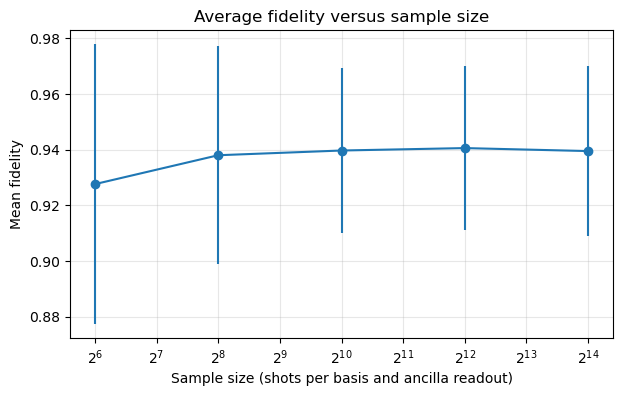

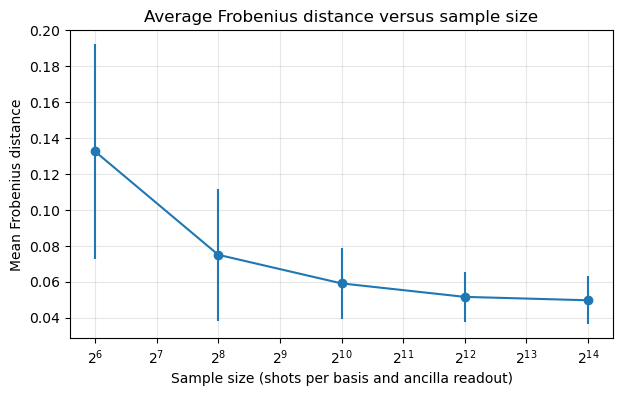

In [7]:

plt.figure(figsize=(7, 4))
plt.errorbar(
    summary_df['sample_size'],
    summary_df['mean_fidelity'],
    yerr=summary_df['std_fidelity'],
    marker='o',
)
plt.xscale('log', base=2)
plt.xlabel('Sample size (shots per basis and ancilla readout)')
plt.ylabel('Mean fidelity')
plt.title('Average fidelity versus sample size')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.errorbar(
    summary_df['sample_size'],
    summary_df['mean_frobenius_distance'],
    yerr=summary_df['std_frobenius_distance'],
    marker='o',
)
plt.xscale('log', base=2)
plt.xlabel('Sample size (shots per basis and ancilla readout)')
plt.ylabel('Mean Frobenius distance')
plt.title('Average Frobenius distance versus sample size')
plt.grid(True, alpha=0.3)
plt.show()


## Optional: save the averaged results to CSV

In [8]:

output_csv = Path.cwd() / 'execution_noisy_summary_results.csv'
summary_df.to_csv(output_csv, index=False)
